In [7]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import torch
import numpy as np
from pathlib import Path

from eval_fluent_deeponet import (
    InterfaceIterationConfig,
    iterative_unknown_interface_inference,
    make_plot_dict_from_iterative_result,
    select_sample_indices_by_ar,
)

from fluent_deeponet import DeepONet, FeatureNormalizer
from deeponet_fluent_dataset import build_fluent_deeponet_dataset

from plot import plot_prediction_imshow_from_points

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
device = torch.device("cuda:3")
ckpt_path = Path("results") / "052426_1" / "checkpoint.pt"
ckpt = torch.load(ckpt_path, map_location=device)

best_model = DeepONet(**ckpt["model_config"]).to(device)
best_model.load_state_dict(ckpt["model_state_dict"])
best_model.eval()


/tmp/ipykernel_2937591/3091633078.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location=device)


DeepONet(
  (branch_net): PointSetBranchNet(
    (point_encoder): Sequential(
      (0): Linear(in_features=13, out_features=128, bias=True)
      (1): GELU(approximate='none')
      (2): Linear(in_features=128, out_features=128, bias=True)
      (3): GELU(approximate='none')
      (4): Linear(in_features=128, out_features=128, bias=True)
    )
    (global_mlp): Sequential(
      (0): Linear(in_features=128, out_features=128, bias=True)
      (1): GELU(approximate='none')
      (2): Linear(in_features=128, out_features=128, bias=True)
      (3): GELU(approximate='none')
      (4): Linear(in_features=128, out_features=512, bias=True)
    )
  )
  (trunk_net): TrunkNet(
    (net): Sequential(
      (0): Linear(in_features=2, out_features=128, bias=True)
      (1): GELU(approximate='none')
      (2): Linear(in_features=128, out_features=128, bias=True)
      (3): GELU(approximate='none')
      (4): Linear(in_features=128, out_features=128, bias=True)
      (5): GELU(approximate='none')
   

In [9]:
ROOT_DIR = Path("/home/hantianl/Documents/PIDIF/runs_2d/rect_ar")

available_ars = list(range(1, 51))

case_files = {
    i: {
        "mesh": ROOT_DIR / f"rect_ar{i:02d}_1e-1mps_2c/rect_ar{i:02d}.msh.h5",
        "dat": ROOT_DIR / f"rect_ar{i:02d}_1e-1mps_2c/case2d.dat.h5",
    }
    for i in available_ars
}

# Quick path check for the ARs used below.
for ar in [10, 20, 30, 50]:
    print(ar, case_files[ar]["mesh"].exists(), case_files[ar]["dat"].exists())

bc_kwargs = {
    "inlet_u": 0.1,
    "inlet_v": 0.0,
    "inlet_T": 273.0,
    "outlet_p": 0.0,
    "top_T": 273.0,
    "bottom_T": 275.0,
    "wall_u": 0.0,
    "wall_v": 0.0,
}

TEST_AR = 50

test_data = build_fluent_deeponet_dataset(
    case_files=case_files,
    ar_list=[TEST_AR],
    n_subdomains=TEST_AR,
    n_interface_points=256,
    n_boundary_points=256,
    interface_placement="fixed",
    interface_jitter=0,
    bc_kwargs=bc_kwargs,
    keep_raw_case_data=False,
)

10 True True
20 True True
30 True True
50 True True


Processing AR=50 realization=0


In [10]:
y_normalizer = FeatureNormalizer.from_state_dict(ckpt["y_normalizer"]).to(device)
local_aspect_mean = float(ckpt["local_aspect_mean"])
local_aspect_std = float(ckpt["local_aspect_std"])
sample_test_ids = select_sample_indices_by_ar(test_data, ar=50)

config = InterfaceIterationConfig(
    max_iter=250,
    tol=1.0e-6,
    mse_mode="normalized",
    relaxation=1.0,
    random_seed=0,
    init_mode="dataset_truth",
    init_std_scale=1.0,
    init_value=0.0,
    init_noise_std=0,
    query_batch_size=32768,
    sample_batch_size=20,
    preserve_wall_corners=False,
    verbose=True,
)

test_result = iterative_unknown_interface_inference(
    model=best_model,
    samples_for_ar=[test_data["samples"][i] for i in sample_test_ids],
    branch_channel_names=test_data["branch_channel_names"],
    device=device,
    y_normalizer=y_normalizer,
    local_aspect_mean=local_aspect_mean,
    local_aspect_std=local_aspect_std,
    config=config,
)

print("Converged:", test_result["converged"], "iterations:", test_result["n_iter"])
print("Final prediction samples:", len(test_result["pred_samples"]))


iter=0000 | interface MSE max=5.759274e-02, mean=3.133293e-03 | converged=0/49
iter=0001 | interface MSE max=7.965391e-02, mean=4.089344e-03 | converged=0/49
iter=0002 | interface MSE max=9.341010e-02, mean=5.154171e-03 | converged=0/49


iter=0003 | interface MSE max=1.062616e-01, mean=6.497991e-03 | converged=0/49
iter=0004 | interface MSE max=1.206390e-01, mean=8.246837e-03 | converged=0/49
iter=0005 | interface MSE max=1.380687e-01, mean=1.058193e-02 | converged=0/49
iter=0006 | interface MSE max=1.600880e-01, mean=1.379761e-02 | converged=0/49
iter=0007 | interface MSE max=1.887561e-01, mean=1.838977e-02 | converged=0/49
iter=0008 | interface MSE max=2.272114e-01, mean=2.519126e-02 | converged=0/49
iter=0009 | interface MSE max=2.805588e-01, mean=3.554811e-02 | converged=0/49
iter=0010 | interface MSE max=3.574613e-01, mean=5.147145e-02 | converged=0/49
iter=0011 | interface MSE max=4.731097e-01, mean=7.563630e-02 | converged=0/49
iter=0012 | interface MSE max=6.590192e-01, mean=1.112237e-01 | converged=0/49
iter=0013 | interface MSE max=9.931051e-01, mean=1.622652e-01 | converged=0/49
iter=0014 | interface MSE max=1.531662e+00, mean=2.372510e-01 | converged=0/49
iter=0015 | interface MSE max=2.447592e+00, mean=3.6

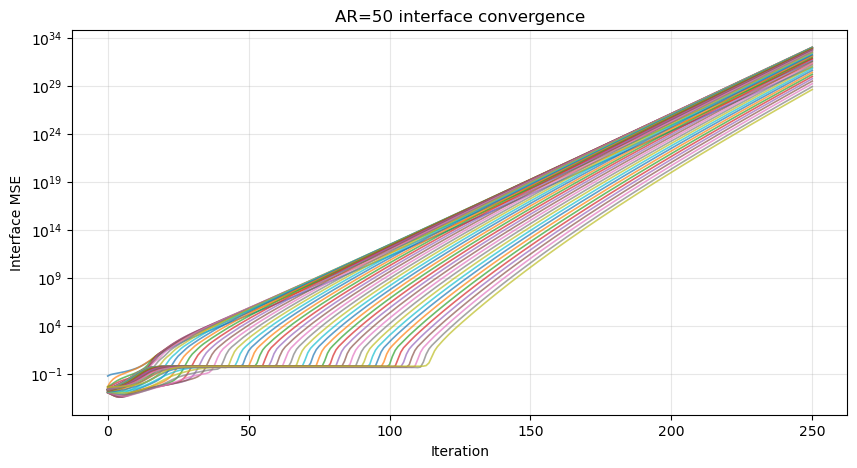

In [11]:
mse_history = test_result["interface_mse_history"]
plt.figure(figsize=(10, 5))
for k in range(mse_history.shape[1]):
    plt.plot(mse_history[:, k], alpha=0.7, linewidth=1.2, label=f"Channel {k}")
plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("Interface MSE")
plt.title(f"AR={TEST_AR} interface convergence")
plt.grid(True, alpha=0.3)
plt.show()

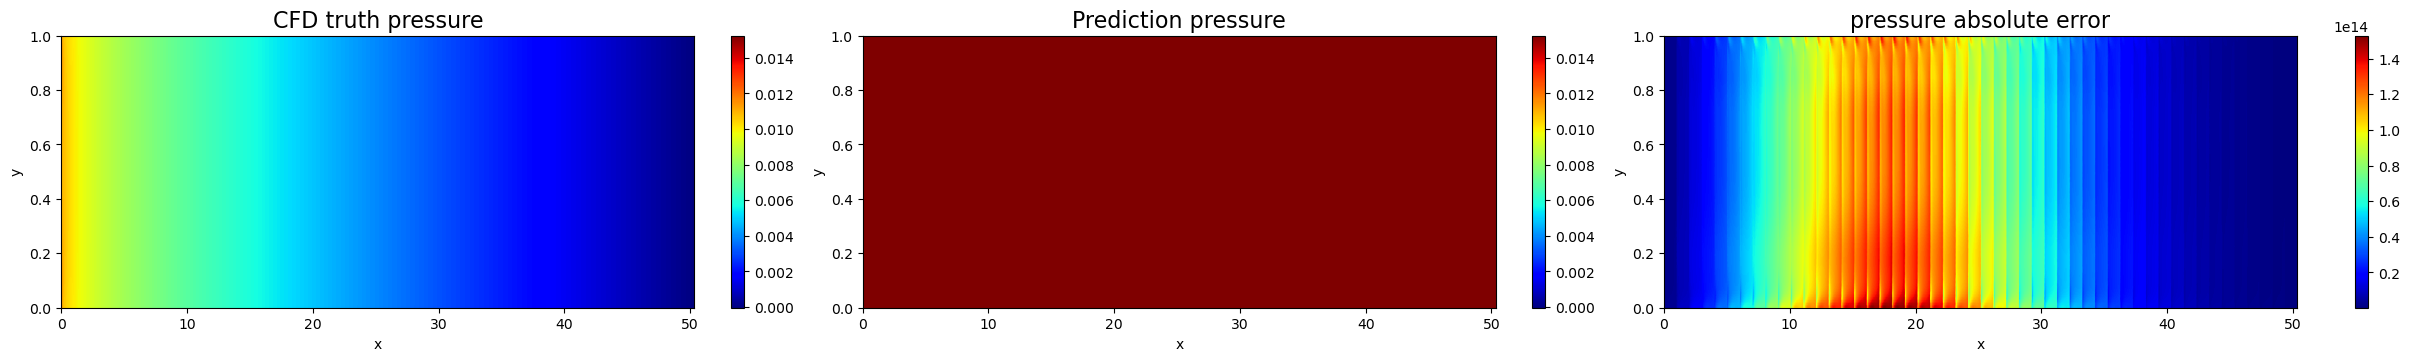

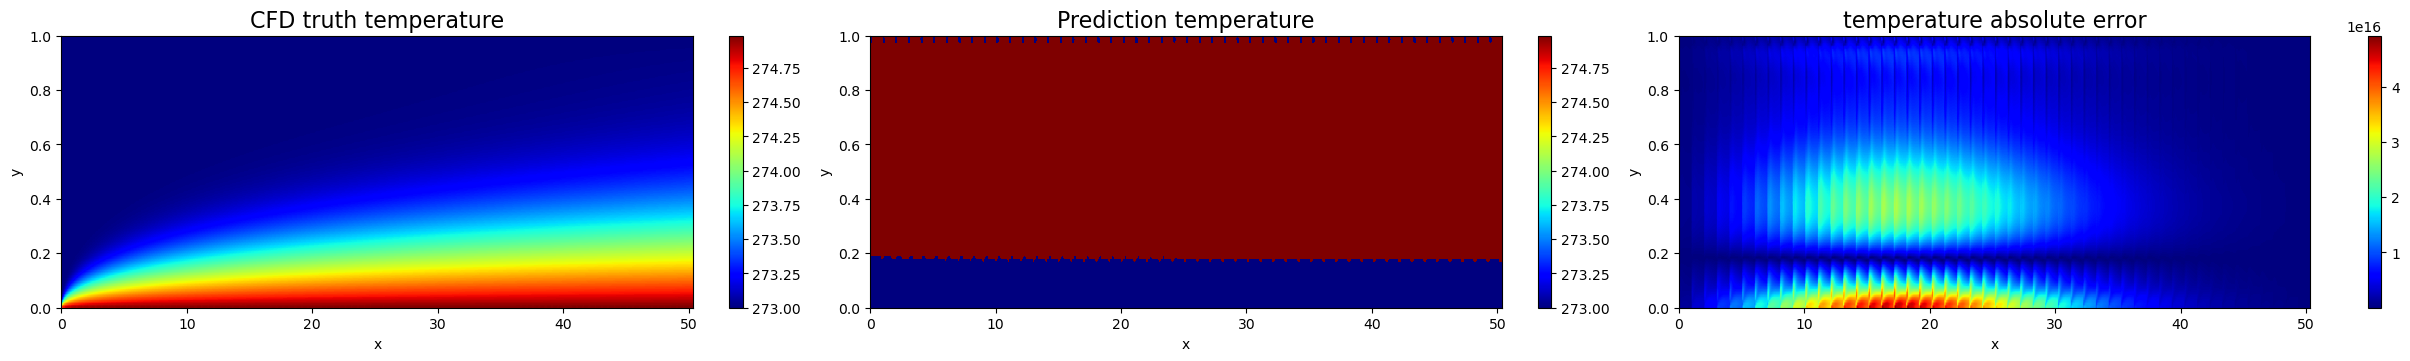

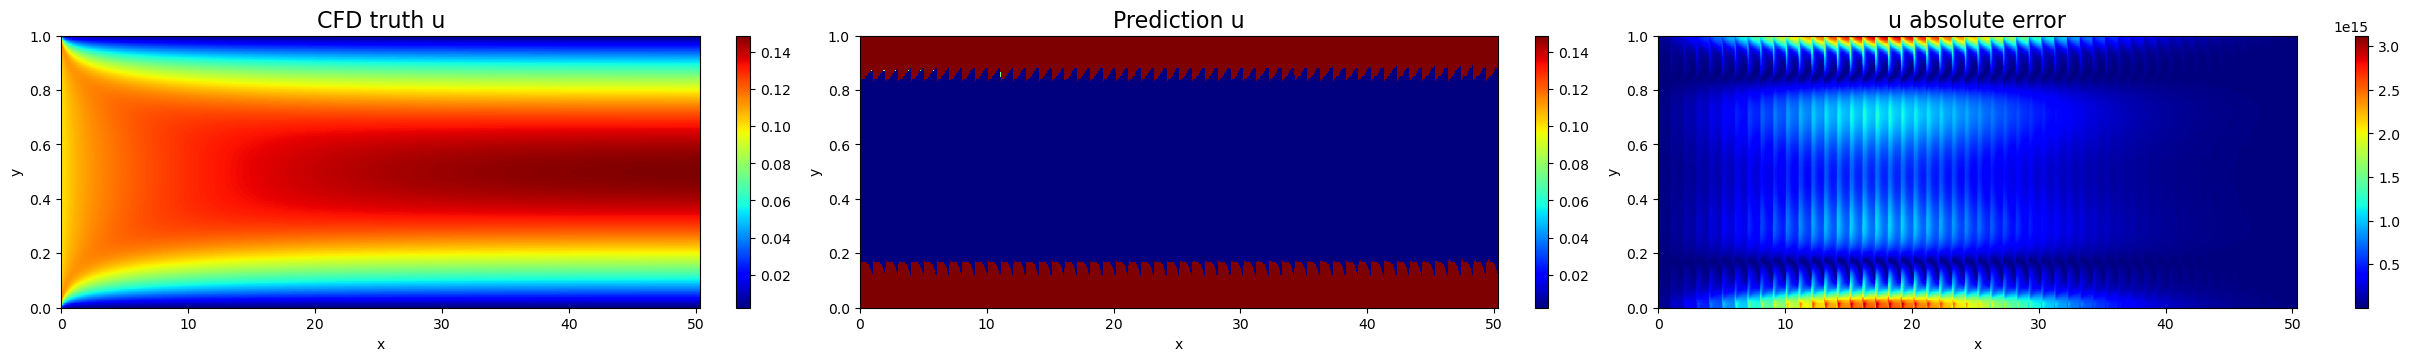

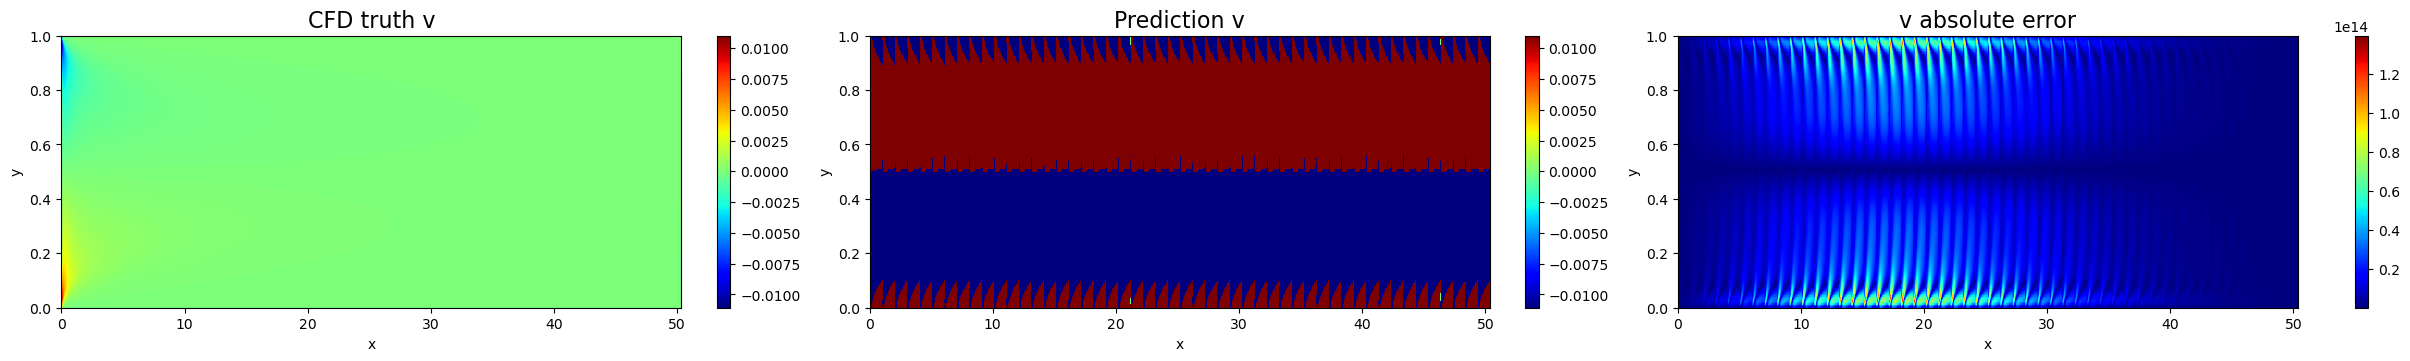

In [12]:
p_plot = make_plot_dict_from_iterative_result(
    result=test_result,
    data=test_data,
    sample_indices=sample_test_ids,
    nondimensionalize_xy=True,
)

output_channel_names = test_data["output_channel_names"]
for field_name in output_channel_names:
    field_idx = output_channel_names.index(field_name)

    plot_prediction_imshow_from_points(
        x=p_plot["x"],
        y=p_plot["y"],
        pred=p_plot["pred"],
        truth=p_plot["truth"],
        field_name=field_name,
        field_idx=field_idx,
        n_y_plot=100,
    )